Generated dataset with 10000 samples.


Training epochs: 100%|██████████| 100/100 [00:09<00:00, 10.79it/s]


Wi changed: True
wa changed: True
Wo changed: True
Training finished.
Evaluating accuracy...
Accuracy: 0.329


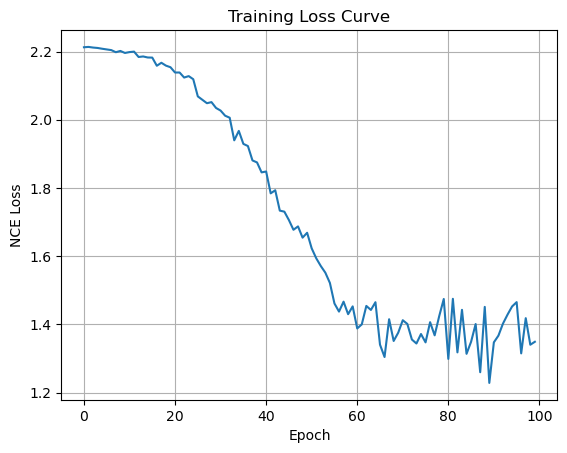

In [1]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import trange
from collections import defaultdict

##################################################
# --- Data generation constants and functions ---
PROBA_COMPLEMENTARY_ITEMS = 0.7
PROBA_NEUTRAL_ITEMS = 0.3
DICT_ITEMS_CLASSES = {
    "nest0": ({0,1,2}, [-1, 1, 0, 0]) ,
    "nest1": ({3,4,5}, [1, -1, 0, 0]),
    "nest2": ({6}, [0, 0, -1, 0]),
    "nest3": ({7}, [0, 0, 0, -1])
}
ASSORTMENT = {0, 1, 2, 3, 4, 5, 6, 7}
AVAILABLE_SETS = list(KEY for KEY, VALUE in DICT_ITEMS_CLASSES.items() if VALUE[0].intersection(ASSORTMENT))

def select_first_item():
    chosen_nest = random.choice(AVAILABLE_SETS)
    chosen_item = random.choice(list(DICT_ITEMS_CLASSES[chosen_nest][0]))
    return chosen_item, chosen_nest

def complete_basket(first_item, first_nest):
    basket = {first_item}
    first_key_index = int(first_nest[-1])
    for key in AVAILABLE_SETS:
        nest, relations = DICT_ITEMS_CLASSES[key]
        if relations[first_key_index] == 1 and random.random() < PROBA_COMPLEMENTARY_ITEMS:
            basket.add(random.choice(list(nest)))
        elif relations[first_key_index] == 0 and random.random() < PROBA_NEUTRAL_ITEMS:
            basket.add(random.choice(list(nest)))
    return basket

def add_noise(basket):
    noise_proba = [0, 0.15]
    for item in ASSORTMENT:
        proba = random.choice(noise_proba)
        if item not in basket and random.random() < proba:
            basket.add(item)
    return list(basket)

##################################################

# --- Parameters ---
I = 8  # Number of items
K = 2 # Embedding dimension
DEFAULT_N_ITEMS_BASKET = 3
N_BASKET = 10000
K_NOISE = 1
TRAINING_EPOCHS = 100
L_R = 0.01

# --- Model ---
class NCEBasketModel(tf.Module):
    def __init__(self, n_items, embedding_dim, K_noise, Q=None, name="NCEBasketModel"):
        super().__init__(name=name)
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.K_noise = K_noise
        self.Wi = tf.Variable(tf.random.normal((n_items, embedding_dim), stddev=0.1), name='Wi')
        self.Wo = tf.Variable(tf.random.normal((n_items, embedding_dim), stddev=0.1), name='Wo')
        self.wa = tf.Variable(tf.random.normal((embedding_dim,), stddev=0.1), name='wa')
        # Noise distribution Q
        if Q is None:
            self.Q = tf.constant([1.0/(n_items-1)]*n_items, dtype=tf.float32)
        else:
            self.Q = tf.constant(Q, dtype=tf.float32)

    def context_embed(self, context_items):
        context_emb = tf.gather(self.Wi, context_items)  
        attn_logits = tf.tensordot(context_emb, self.wa, axes=1)  
        attn_weights = tf.nn.softmax(attn_logits)
        context_vec = tf.reduce_sum(context_emb * tf.expand_dims(attn_weights, -1), axis=0)  # [K]
        return context_vec

    def score(self, context_vec, item):
        return tf.tensordot(self.Wo[item], context_vec, axes=1)

    
    def nce_loss(self, context_items, target_item):

        context_vec = self.context_embed(context_items)
        pos_score = self.score(context_vec, target_item)
        # Negative sampling: exclude basket items
        all_items = tf.range(self.n_items, dtype=tf.int32)
        mask = ~tf.reduce_any(tf.equal(all_items[:, None], tf.expand_dims(context_items, 0)), axis=1)
        neg_pool = tf.boolean_mask(all_items, mask)
        neg_items = tf.random.shuffle(neg_pool)[:self.K_noise]
        # NCE probabilities
        KQ = self.K_noise * self.Q[target_item]
        P_1 = tf.exp(pos_score) / (tf.exp(pos_score) + KQ)
        loss = -tf.math.log(P_1 )
        for i in neg_items:
            neg_score = self.score(context_vec, i)
            KQ_neg = self.K_noise * self.Q[i]
            P_0 = 1-(tf.exp(neg_score) / (tf.exp(neg_score) + KQ_neg))
            loss -= tf.math.log(P_0 )
        return loss

    """
    def train_step(self, batch, optimizer):
        with tf.GradientTape() as tape:
            batch_inputs = []
            batch_labels = []
            for context_items, target_item in batch:
                context_vec = self.context_embed(context_items)
                batch_inputs.append(context_vec)
                batch_labels.append([target_item])
            batch_inputs = tf.stack(batch_inputs)  
            batch_labels = tf.constant(batch_labels, dtype=tf.int64) 
            loss = tf.reduce_mean(
                tf.nn.nce_loss(
                    weights=self.Wo,       
                    biases=self.bo,    
                    labels=batch_labels,  
                    inputs=batch_inputs,    
                    num_sampled=self.K_noise,
                    num_classes=self.n_items
                )
            )
        grads = tape.gradient(loss, [self.Wi, self.wa, self.Wo, self.bo])
        optimizer.apply_gradients(zip(grads, [self.Wi, self.wa, self.Wo, self.bo]))
        return loss.numpy()
    """
            
    def train_step(self, batch, optimizer):
        with tf.GradientTape() as tape:
            total_loss = 0.0
            for context_items, target_item in batch:
                loss = self.nce_loss(context_items, target_item)
                total_loss += loss
        grads = tape.gradient(total_loss, [self.Wi, self.wa, self.Wo])
        optimizer.apply_gradients(zip(grads, [self.Wi, self.wa, self.Wo]))
        return total_loss.numpy() / len(batch)

    def predict(self, context_items):
        context_vec = self.context_embed(context_items)
        scores = tf.tensordot(self.Wo, context_vec, axes=1) 
        return scores

##################################################

# --- Random Data preparation ---
def generate_dataset(n_basket, n_items_basket=DEFAULT_N_ITEMS_BASKET):
    baskets = []
    count = 0
    while count < n_basket:
        first_item, first_nest = select_first_item()
        basket = complete_basket(first_item, first_nest)
        basket = add_noise(basket)
        if len(basket) >= n_items_basket:
            baskets.append(basket)
            count += 1
    # For each basket, create (context, target_item) pairs
    dataset = []
    for basket in baskets:
        target_item = random.choice(basket)
        context_items = [i for i in basket if i != target_item]
        dataset.append((tf.constant(context_items, dtype=tf.int32), target_item))
    return dataset

# --- Stratified dataset generation ---
def generate_stratified_dataset(n_samples, min_per_item=50):
    baskets = []
    item_counts = defaultdict(int)
    while min(item_counts.values() or [0]) < min_per_item:
        first_item, first_nest = select_first_item()
        basket = complete_basket(first_item, first_nest)
        basket = add_noise(basket)
        if len(basket) < 2:
            continue
        # Only add if it helps balance
        if any(item_counts[i] < min_per_item for i in basket):
            baskets.append(basket)
            for i in basket:
                item_counts[i] += 1
        if len(baskets) >= n_samples:
            break
    dataset = []
    for basket in baskets:
        target_item = random.choice(basket)
        context_items = [i for i in basket if i != target_item]
        dataset.append((tf.constant(context_items, dtype=tf.int32), target_item))
    return dataset


##################################################
# --- Training ---
def train_model():
    dataset = generate_dataset(N_BASKET) # or generate_dataset(N_BASKET)
    print(f"Generated dataset with {len(dataset)} samples.")
    model = NCEBasketModel(I, K, K_NOISE)
    optimizer = tf.keras.optimizers.Adam(L_R)
    loss_history = []
    Wi, wa, Wo = model.Wi, model.wa, model.Wo
    Wi_init = Wi.numpy().copy()
    wa_init = wa.numpy().copy()
    Wo_init = Wo.numpy().copy()
    for epoch in trange(TRAINING_EPOCHS, desc="Training epochs"):
        batch = random.sample(dataset, min(16, len(dataset)))
        loss = model.train_step(batch, optimizer)
        loss_history.append(loss)
    print("Wi changed:", not np.allclose(Wi.numpy(), Wi_init))
    print("wa changed:", not np.allclose(wa.numpy(), wa_init))
    print("Wo changed:", not np.allclose(Wo.numpy(), Wo_init))
    return model, dataset, loss_history

# --- Evaluation ---
def evaluate(model, dataset):
    correct = 0
    for context_items, target_item in dataset:
        scores = model.predict(context_items)
        # Mask context items so they can't be predicted
        mask = np.ones(I, dtype=bool)
        mask[context_items.numpy()] = False
        scores_np = scores.numpy()
        scores_np[~mask] = -np.inf
        pred = np.argmax(scores_np)
        if pred == target_item:
            correct += 1
    return correct / len(dataset)

# --- Main ---
if __name__ == "__main__":
    model, dataset, loss_history = train_model()
    print("Training finished.")
    print("Evaluating accuracy...")
    acc = evaluate(model, dataset)
    print(f"Accuracy: {acc:.3f}")
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("NCE Loss")
    plt.title("Training Loss Curve")
    plt.grid(True)
    plt.show()

Model predictions P(i|j) on random baskets:
 [[0.01  0.012 0.    0.    0.014 0.014 0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.038 0.035 0.055 0.    0.044 0.041 0.    0.   ]
 [0.112 0.111 0.103 0.159 0.102 0.108 0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.241 0.238 0.259 0.243 0.275 0.253 0.396 0.   ]
 [0.599 0.604 0.584 0.599 0.566 0.585 0.604 1.   ]]


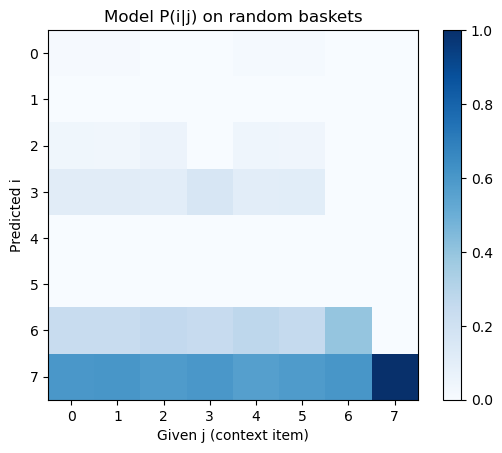

In [2]:
##################################################
# Test the model on random baskets

# Parameters

N_RANDOM_BASKETS = 1000
MIN_BASKET_SIZE = 2
MAX_BASKET_SIZE = 5

# Generate random baskets
random_baskets = []
for _ in range(N_RANDOM_BASKETS):
    basket_size = np.random.randint(MIN_BASKET_SIZE, MAX_BASKET_SIZE + 1)
    basket = np.random.choice(range(I), size=basket_size, replace=False).tolist()
    random_baskets.append(basket)

# Collect predictions: P(i|context)
P_ij_random = np.zeros((I, I))  # Rows: predicted, Cols: context item

for basket in random_baskets:
    for j in basket:
        context = [i for i in basket if i != j]
        if not context:
            continue
        scores = model.predict(tf.constant(context, dtype=tf.int32)).numpy()
        # Mask context items so they can't be predicted
        mask = np.ones(I, dtype=bool)
        mask[context] = False
        scores[~mask] = -np.inf
        i_pred = np.argmax(scores)
        P_ij_random[i_pred, j] += 1

# Normalize: P(i|j) = count(i,j) / count(j)
P_ij_random_norm = P_ij_random / (np.sum(P_ij_random, axis=0, keepdims=True) + 1e-10)

print("Model predictions P(i|j) on random baskets:\n", np.round(P_ij_random_norm, 3))
import matplotlib.pyplot as plt
plt.imshow(P_ij_random_norm, cmap='Blues')
plt.xlabel('Given j (context item)')
plt.ylabel('Predicted i')
plt.title('Model P(i|j) on random baskets')
plt.colorbar()
plt.show()

Empirical P(i|j) from data:
 [[0.    0.056 0.064 0.134 0.138 0.145 0.125 0.118]
 [0.056 0.    0.057 0.138 0.136 0.143 0.126 0.126]
 [0.06  0.052 0.    0.125 0.128 0.129 0.117 0.111]
 [0.13  0.132 0.13  0.    0.076 0.069 0.113 0.116]
 [0.142 0.139 0.141 0.081 0.    0.058 0.124 0.129]
 [0.157 0.154 0.15  0.078 0.061 0.    0.134 0.128]
 [0.239 0.238 0.239 0.224 0.231 0.238 0.    0.272]
 [0.217 0.23  0.219 0.22  0.231 0.217 0.262 0.   ]]


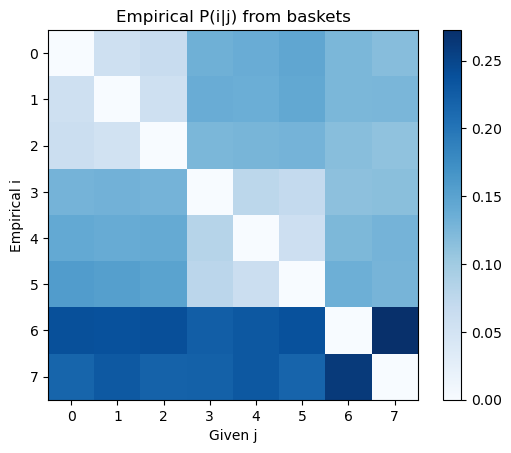

In [3]:
##################################################
# Original distribution

# Generate baskets
N_SAMPLES = 1000
baskets = []
count = 0
while count < N_SAMPLES:
    first_item, first_nest = select_first_item()
    basket = complete_basket(first_item, first_nest)
    basket = add_noise(basket)
    if len(basket) < 2:
        continue
    baskets.append(basket)
    count += 1

# Compute empirical P(i|j) from baskets
P_ij_true = np.zeros((I, I))
for basket in baskets:
    for i in basket:
        for j in basket:
            if i != j:
                P_ij_true[i, j] += 1

# Normalize: P(i|j) = count(i,j) / count(j)
P_ij_true_norm = P_ij_true / (np.sum(P_ij_true, axis=0, keepdims=True) + 1e-10)

print("Empirical P(i|j) from data:\n", np.round(P_ij_true_norm, 3))
plt.imshow(P_ij_true_norm, cmap='Blues')
plt.xlabel('Given j')
plt.ylabel('Empirical i')
plt.title('Empirical P(i|j) from baskets')
plt.colorbar()
plt.show()

Model softmax P(i|j):
 [[0.167 0.099 0.101 0.101 0.104 0.096 0.086 0.09 ]
 [0.095 0.161 0.094 0.092 0.092 0.098 0.086 0.087]
 [0.109 0.105 0.176 0.104 0.104 0.104 0.097 0.092]
 [0.11  0.104 0.106 0.186 0.105 0.105 0.092 0.097]
 [0.086 0.079 0.081 0.08  0.146 0.086 0.076 0.073]
 [0.079 0.086 0.081 0.081 0.087 0.147 0.076 0.073]
 [0.16  0.17  0.176 0.162 0.175 0.174 0.309 0.159]
 [0.195 0.196 0.185 0.194 0.187 0.19  0.178 0.329]]


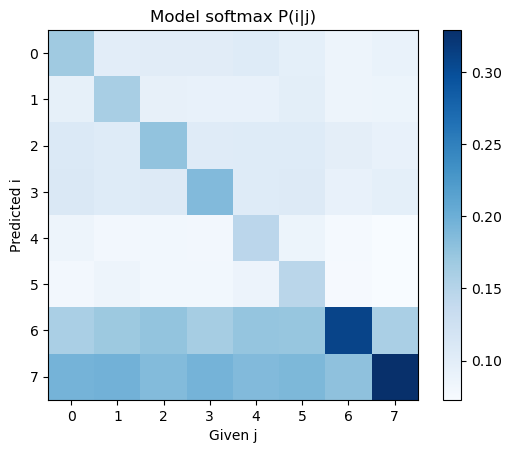

In [4]:
##################################################
# Test the model on random baskets
# Visualize the P(i|j) matrix with softmax


P_ij_soft = np.zeros((I, I))
for basket in random_baskets:
    for j in basket:
        context_wo_j = [i for i in basket if i != j]
        if not context_wo_j:
            continue
        scores = model.predict(tf.constant(context_wo_j, dtype=tf.int32)).numpy()
        mask = np.ones(I, dtype=bool)
        mask[context_wo_j] = False
        scores[~mask] = -np.inf
        probs = np.exp(scores - np.max(scores))  # for numerical stability
        probs = probs * mask  # zero out masked
        probs = probs / (probs.sum() + 1e-10)
        P_ij_soft[:, j] += probs

P_ij_soft_norm = P_ij_soft / (np.sum(P_ij_soft, axis=0, keepdims=True) + 1e-10)

print("Model softmax P(i|j):\n", np.round(P_ij_soft_norm, 3))
plt.imshow(P_ij_soft_norm, cmap='Blues')
plt.xlabel('Given j')
plt.ylabel('Predicted i')
plt.title('Model softmax P(i|j)')
plt.colorbar()
plt.show()

In [5]:
##################################################
# Grid search for best parameters

from itertools import product
import numpy as np
import tensorflow as tf
from NCEBasketModel import NCEBasketModel
from generate_dataset import generate_dataset


def pij_distance(P1, P2):
    return np.mean((P1 - P2) ** 2)

param_grid = {
    'K': [2, 4, 8],
    'K_NOISE': [4, 6, 8],
    'L_R': [0.01, 0.05, 0.1]
}

best_score = float('inf')
best_params = None

for K, K_NOISE, L_R in product(param_grid['K'], param_grid['K_NOISE'], param_grid['L_R']):
    print(f"Testing K={K}, K_NOISE={K_NOISE}, L_R={L_R}")
    # Train model with these parameters
    model = NCEBasketModel(I, K, K_NOISE)
    optimizer = tf.keras.optimizers.Adam(L_R)
    dataset = generate_dataset(N_BASKET)
    for epoch in range(30):  # Fewer epochs for speed
        batch = random.sample(dataset, min(16, len(dataset)))
        model.train_step(batch, optimizer)
    # Compute model P(i|j) using softmax
    P_ij_soft = np.zeros((I, I))
    for basket in baskets:
        for j in basket:
            context_wo_j = [i for i in basket if i != j]
            if not context_wo_j:
                continue
            scores = model.predict(tf.constant(context_wo_j, dtype=tf.int32)).numpy()
            mask = np.ones(I, dtype=bool)
            mask[context_wo_j] = False
            scores[~mask] = -np.inf
            probs = np.exp(scores - np.max(scores))
            probs = probs * mask
            probs = probs / (probs.sum() + 1e-10)
            P_ij_soft[:, j] += probs
    P_ij_soft_norm = P_ij_soft / (np.sum(P_ij_soft, axis=0, keepdims=True) + 1e-10)
    # Compute distance
    score = pij_distance(P_ij_soft_norm, P_ij_true_norm)
    print(f"Distance: {score:.5f}")
    if score < best_score:
        best_score = score
        best_params = {'K': K, 'K_NOISE': K_NOISE, 'L_R': L_R}

print("Best params:", best_params)
print("Best distance:", best_score)

ModuleNotFoundError: No module named 'NCEBasketModel'